## Important Libraries

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from collections import Counter
import glob
import os
import re

import warnings
warnings.filterwarnings('ignore')

In [3]:
# For cleaner plots
sns.set(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 6)
pd.set_option('display.max_columns', None)

## Read the Data from a folder

In [4]:
files = [file for file in os.listdir('../data/raw/')]
data = pd.DataFrame()
for file in files:
    all_csvs = pd.read_csv('../data/raw/' + file)
    data = pd.concat([all_csvs, data])   
# data.to_csv('../data/processed/uk_pay_gap_2017-25_.csv', index=False)

In [5]:
df = pd.read_csv('../data/processed/uk_pay_gap_2017-25_.csv')

In [6]:
df.head()

,EmployerName,EmployerId,Address,PostCode,CompanyNumber,SicCodes,DiffMeanHourlyPercent,DiffMedianHourlyPercent,DiffMeanBonusPercent,DiffMedianBonusPercent,MaleBonusPercent,FemaleBonusPercent,MaleLowerQuartile,FemaleLowerQuartile,MaleLowerMiddleQuartile,FemaleLowerMiddleQuartile,MaleUpperMiddleQuartile,FemaleUpperMiddleQuartile,MaleTopQuartile,FemaleTopQuartile,CompanyLinkToGPGInfo,ResponsiblePerson,EmployerSize,CurrentName,SubmittedAfterTheDeadline,DueDate,DateSubmitted
0,1ST HOME CARE LTD.,17484,"Suite 1, Ground Floor Academy House, 1346 Shet...",G32 9AT,SC272838,"86900,\n88100",-0.72,0.06,NaN,NaN,0.0,0.0,14.71,85.29,5.89,94.11,11.77,88.23,14.71,85.29,NaN,David Sargent (CEO),Less than 250,1ST HOME CARE LTD.,False,2025/04/05 00:00:00,2024/07/01 15:43:41
1,6 POINT 6 LIMITED,22664,"30 Fenchurch Street, London, England, EC3M 3BD",EC3M 3BD,07946687,62020,22.00,24.00,15.00,33.0,92.0,87.0,58.00,42.00,69.00,31.00,82.00,18.00,89.00,11.00,NaN,Janet Coulthurst (Chief of Staff),250 to 499,6 POINT 6 LIMITED,False,2025/04/05 00:00:00,2024/12/16 11:12:30
2,725 LIMITED,17859,"48 High Street, Gravesend, Kent, England, DA11...",DA11 0AY,05983359,"41100,\n78200",2.50,3.78,NaN,NaN,0.0,0.0,31.00,69.00,31.00,69.00,31.00,69.00,51.00,49.00,NaN,DIPESH LIMBU (ACCOUNTANT),250 to 499,725 LIMITED,False,2025/04/05 00:00:00,2024/12/16 15:06:04
3,A J RAYSON LIMITED,23378,"Bartle House, Oxford Court, Manchester, Englan...",M2 3WQ,14187704,70229,1.37,5.24,NaN,NaN,0.0,0.0,9.00,91.00,21.00,79.00,22.00,78.00,35.80,64.20,NaN,Abigail Rayson (Director),250 to 499,A J RAYSON LIMITED,False,2025/04/05 00:00:00,2024/05/20 10:03:35
4,A P P WHOLESALE LIMITED,21477,"Unit 1 Radford Industrial Estate, Goodhall Str...",NW10 6UA,06552800,46740,-4.26,15.13,-33.39,-20.0,88.0,95.0,91.94,8.06,86.89,13.11,76.67,23.33,84.17,15.83,https://www.lordsgrouptradingplc.co.uk/about-u...,Anne Prince (Group HR Director),Less than 250,A P P WHOLESALE LIMITED,False,2025/04/05 00:00:00,2024/09/17 13:59:33


## Data Exploration

Data exploration is a critical step in the data analysis process, where you examine the dataset to gain a preliminary understanding of the data, detect patterns, and identify potential issues that may need further investigation. Data exploration is important because it helps to provide a solid foundation for subsequent data analysis tasks, hypothesis testing and data visualization.

In [7]:
df.shape

(72810, 27)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72810 entries, 0 to 72809
Data columns (total 27 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   EmployerName               72810 non-null  object 
 1   EmployerId                 72810 non-null  int64  
 2   Address                    72714 non-null  object 
 3   PostCode                   72522 non-null  object 
 4   CompanyNumber              63108 non-null  object 
 5   SicCodes                   68080 non-null  object 
 6   DiffMeanHourlyPercent      72810 non-null  float64
 7   DiffMedianHourlyPercent    72810 non-null  float64
 8   DiffMeanBonusPercent       58000 non-null  float64
 9   DiffMedianBonusPercent     57998 non-null  float64
 10  MaleBonusPercent           72810 non-null  float64
 11  FemaleBonusPercent         72810 non-null  float64
 12  MaleLowerQuartile          72411 non-null  float64
 13  FemaleLowerQuartile        72411 non-null  flo

- Noticed missing values

In [9]:
df.isnull().sum()

EmployerName                     0
EmployerId                       0
Address                         96
PostCode                       288
CompanyNumber                 9702
SicCodes                      4730
DiffMeanHourlyPercent            0
DiffMedianHourlyPercent          0
DiffMeanBonusPercent         14810
DiffMedianBonusPercent       14812
MaleBonusPercent                 0
FemaleBonusPercent               0
MaleLowerQuartile              399
FemaleLowerQuartile            399
MaleLowerMiddleQuartile        399
FemaleLowerMiddleQuartile      399
MaleUpperMiddleQuartile        399
FemaleUpperMiddleQuartile      399
MaleTopQuartile                399
FemaleTopQuartile              399
CompanyLinkToGPGInfo         25860
ResponsiblePerson            12659
EmployerSize                     0
CurrentName                      0
SubmittedAfterTheDeadline        0
DueDate                          0
DateSubmitted                    0
dtype: int64

In [10]:
# Missing value count and percentage
missing_df = df.isnull().sum().reset_index()
missing_df.columns = ['Column', 'MissingValues']
missing_df['MissingPercentage'] = 100 * missing_df['MissingValues'] / len(df)
missing_df = missing_df.sort_values(by='MissingPercentage', ascending=False)

# Display missing value summary
missing_df

,Column,MissingValues,MissingPercentage
20,CompanyLinkToGPGInfo,25860,35.517099
9,DiffMedianBonusPercent,14812,20.343359
8,DiffMeanBonusPercent,14810,20.340613
21,ResponsiblePerson,12659,17.386348
4,CompanyNumber,9702,13.325093
5,SicCodes,4730,6.496360
14,MaleLowerMiddleQuartile,399,0.548002
13,FemaleLowerQuartile,399,0.548002
12,MaleLowerQuartile,399,0.548002
16,MaleUpperMiddleQuartile,399,0.548002


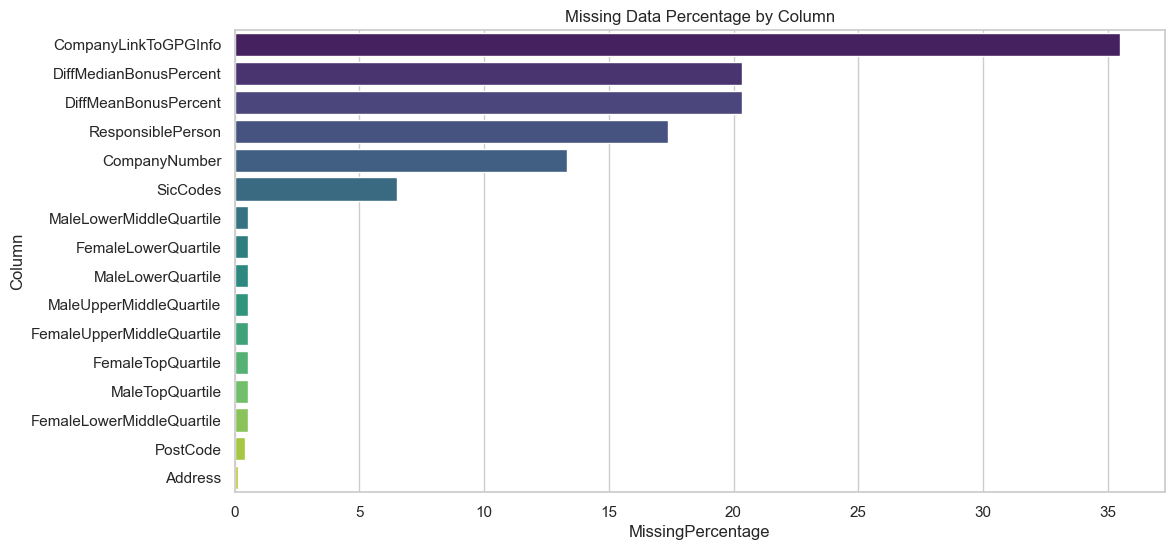

In [11]:
# Visualize
plt.figure(figsize=(12, 6))
sns.barplot(data=missing_df[missing_df.MissingPercentage > 0], 
            x='MissingPercentage', 
            y='Column', 
            palette='viridis')
plt.title('Missing Data Percentage by Column')
plt.show()

In [12]:
df[df['CompanyLinkToGPGInfo'].isna()].head(3)

,EmployerName,EmployerId,Address,PostCode,CompanyNumber,SicCodes,DiffMeanHourlyPercent,DiffMedianHourlyPercent,DiffMeanBonusPercent,DiffMedianBonusPercent,MaleBonusPercent,FemaleBonusPercent,MaleLowerQuartile,FemaleLowerQuartile,MaleLowerMiddleQuartile,FemaleLowerMiddleQuartile,MaleUpperMiddleQuartile,FemaleUpperMiddleQuartile,MaleTopQuartile,FemaleTopQuartile,CompanyLinkToGPGInfo,ResponsiblePerson,EmployerSize,CurrentName,SubmittedAfterTheDeadline,DueDate,DateSubmitted
0,1ST HOME CARE LTD.,17484,"Suite 1, Ground Floor Academy House, 1346 Shet...",G32 9AT,SC272838,"86900,\n88100",-0.72,0.06,NaN,NaN,0.0,0.0,14.71,85.29,5.89,94.11,11.77,88.23,14.71,85.29,NaN,David Sargent (CEO),Less than 250,1ST HOME CARE LTD.,False,2025/04/05 00:00:00,2024/07/01 15:43:41
1,6 POINT 6 LIMITED,22664,"30 Fenchurch Street, London, England, EC3M 3BD",EC3M 3BD,07946687,62020,22.00,24.00,15.0,33.0,92.0,87.0,58.00,42.00,69.00,31.00,82.00,18.00,89.00,11.00,NaN,Janet Coulthurst (Chief of Staff),250 to 499,6 POINT 6 LIMITED,False,2025/04/05 00:00:00,2024/12/16 11:12:30
2,725 LIMITED,17859,"48 High Street, Gravesend, Kent, England, DA11...",DA11 0AY,05983359,"41100,\n78200",2.50,3.78,NaN,NaN,0.0,0.0,31.00,69.00,31.00,69.00,31.00,69.00,51.00,49.00,NaN,DIPESH LIMBU (ACCOUNTANT),250 to 499,725 LIMITED,False,2025/04/05 00:00:00,2024/12/16 15:06:04


# **Exploratory Data Analysis**

Exploratory Data Analysis (EDA) is the process of analyzing and summarizing data to find patterns, relationships, and insights that can help inform business decisions. EDA is an important step in data analysis as it allows us to understand the data and identify potential problems such as outliers, missing values, or data inconsistencies. EDA can involve visualizing data using graphs and charts, calculating summary statistics such as means and medians, and identifying correlations between variables.

## Univarte Analysis

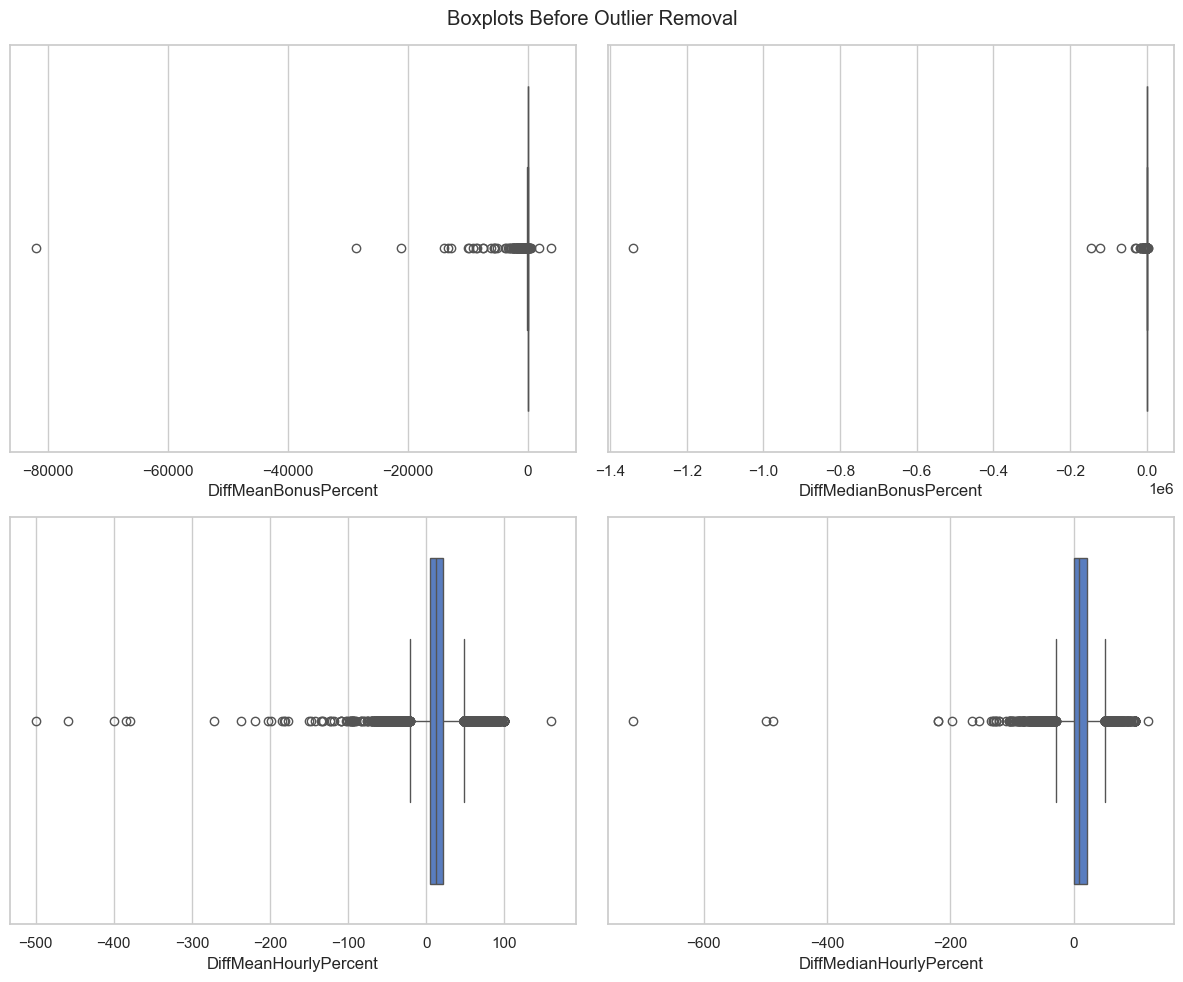

In [13]:
# 1. Box plots before outlier removal
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
sns.boxplot(ax=axes[0, 0], x=df['DiffMeanBonusPercent'])
sns.boxplot(ax=axes[0, 1], x=df['DiffMedianBonusPercent'])
sns.boxplot(ax=axes[1, 0], x=df['DiffMeanHourlyPercent'])
sns.boxplot(ax=axes[1, 1], x=df['DiffMedianHourlyPercent'])
fig.suptitle('Boxplots Before Outlier Removal')
plt.tight_layout()

# Show before plots
plt.show()

## Biavariate Analysis

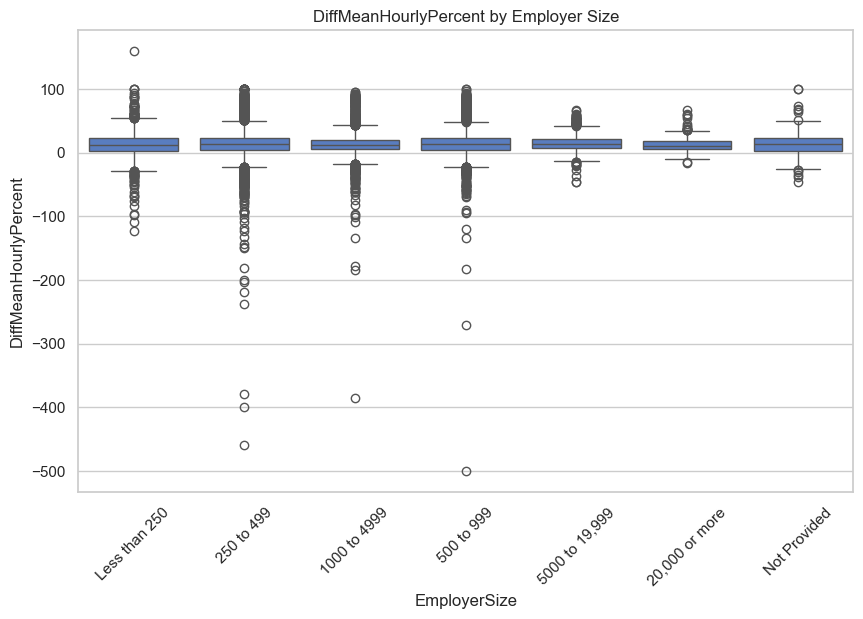

In [14]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='EmployerSize', y='DiffMeanHourlyPercent', data=df)
plt.title('DiffMeanHourlyPercent by Employer Size')
plt.xticks(rotation=45)
plt.show()

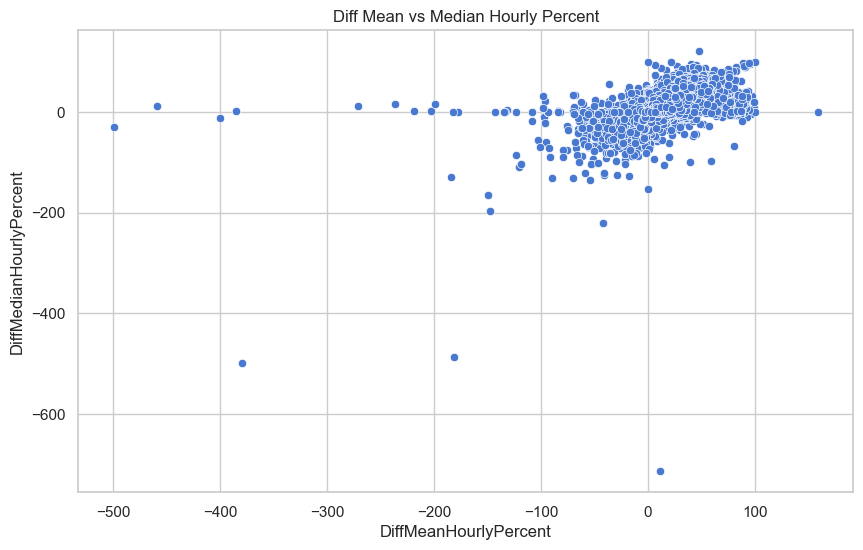

In [15]:
sns.scatterplot(data=df, x='DiffMeanHourlyPercent', y='DiffMedianHourlyPercent')
plt.title('Diff Mean vs Median Hourly Percent')
plt.show()

## Correaltion Analysis

Correlation coefficient is used to measure the strength of relationship between two variables. It indicates that as the value of one variable changes the other variable changes in a specific direction with some magnitude. There are various ways to find correlation between two variables, one of which is Pearson correlation coefficient. It measures the linear relationship between two continuous variables.

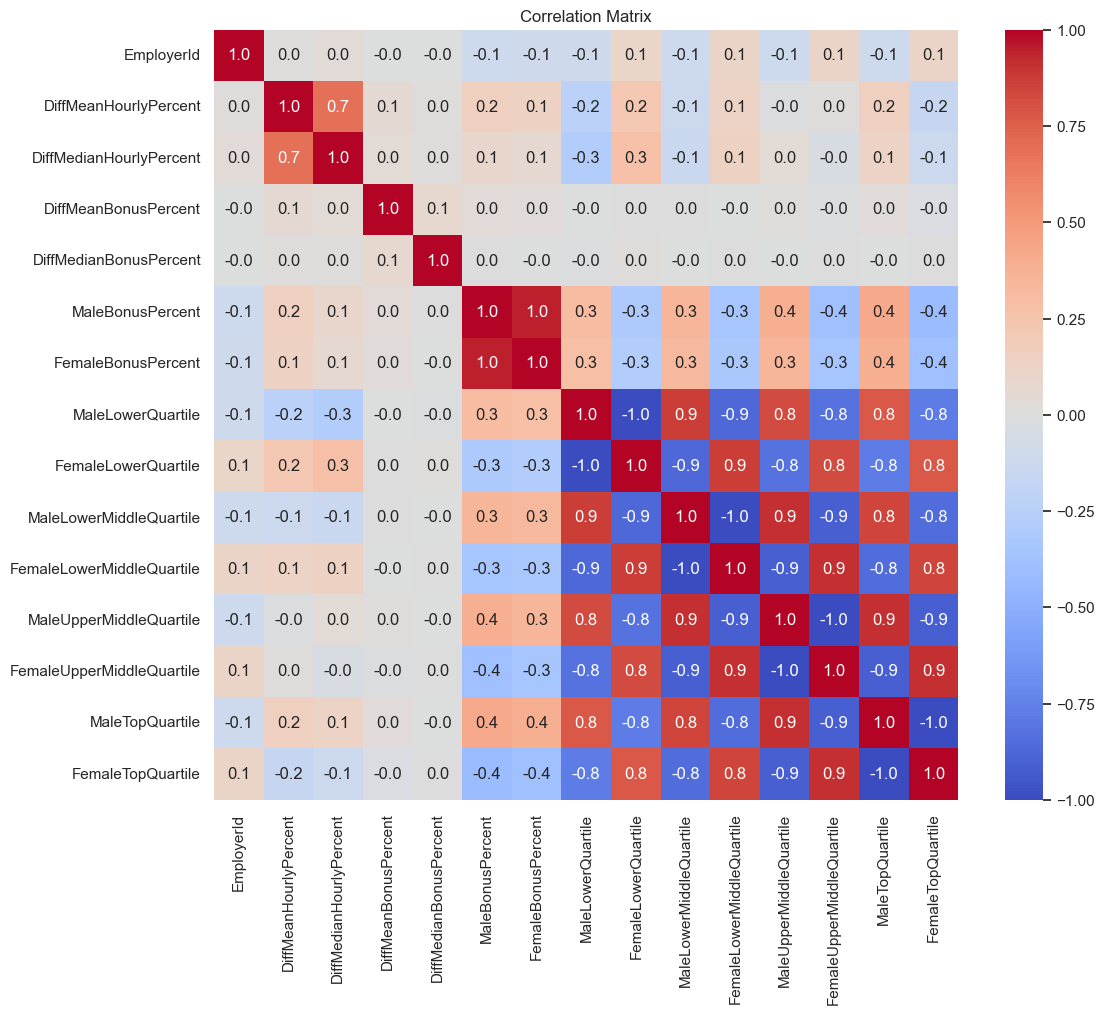

In [16]:
num_cols = df.select_dtypes(include=['float64', 'int64']).columns

plt.figure(figsize=(12, 10))
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, fmt=".1f", cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix')
plt.show()

## Pair Plots

Pair plots are a type of visualization that displays the pairwise relationships between variables in a dataset. They are particularly useful in identifying patterns and relationships between multiple variables at once. Pair plots are essentially a grid of scatterplots that show the relationships between each pair of variables in a dataset.

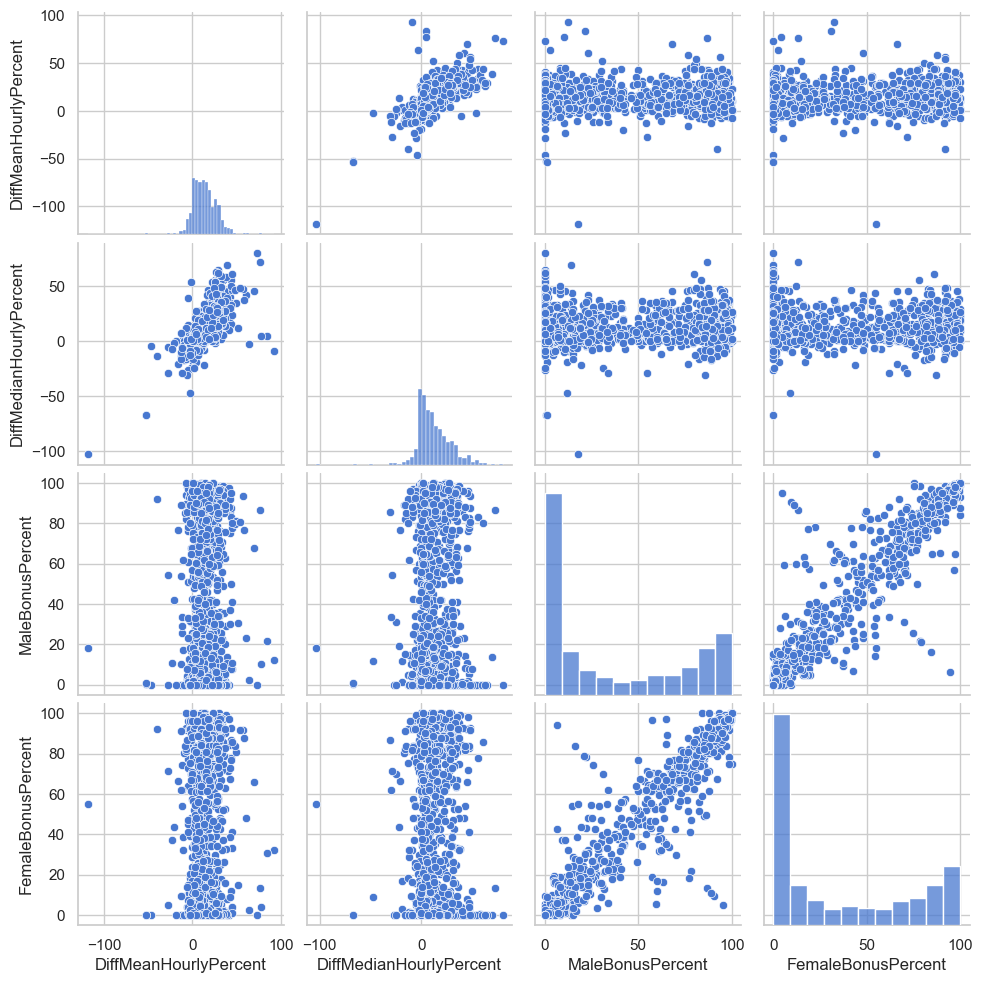

In [17]:
sample_df = df.sample(1000, random_state=42)  # speed it up
sns.pairplot(sample_df[['DiffMeanHourlyPercent', 'DiffMedianHourlyPercent', 
                        'MaleBonusPercent', 'FemaleBonusPercent']])
plt.show()

# Key Insights from Gender Pay Gap EDA Analysis

## Data Quality Observations
- **Extreme Outliers**: The boxplots reveal significant outliers in the bonus pay gap metrics, with some values reaching -80,000 to 0 for mean bonus differences and up to -1.4 million for median bonus differences.
- **Data Cleaning Approach**: The analysis properly separated pre-outlier removal visualizations to understand the raw data distribution before cleaning.
- **Distribution Characteristics**: Hourly pay gap metrics show more normal distributions while bonus metrics are heavily skewed with extreme values.

## Structural Insights

### Pay Gap Patterns
- **Hourly Pay Gap Consistency**: Mean and median hourly pay gaps (bottom panels of Image 1) show similar patterns with most values concentrated near zero but skewing negative (indicating male advantage).
- **Strong Correlation**: Image 3 shows tight correlation (0.7) between mean and median hourly pay gap measures, suggesting consistency in how the gap manifests across companies.
- **Size Independence**: Image 2 reveals that employer size has minimal impact on hourly pay gaps, with all size categories showing similar median values and spread.

### Bonus Gap Dynamics
- **Extreme Values**: Bonus gap metrics show the most problematic outliers, suggesting either data quality issues or truly extreme disparity cases requiring investigation.
- **Low Correlations**: The correlation matrix (Image 4) shows bonus pay gaps have minimal correlation with hourly pay gaps (0.1 or less), indicating they represent different aspects of pay inequality.
- **Distribution Patterns**: Male and female bonus percentages (Image 5, bottom rows) show similar broad distributions but different concentrations, with male bonuses skewing higher.

### Demographic Relationships
- **Gender Balance Trade-offs**: The correlation matrix reveals strong negative correlations (-0.8 to -1.0) between male and female representation in each quartile, confirming the zero-sum nature of gender representation.
- **Quartile Connections**: Strong positive correlations (0.8-0.9) exist between adjacent quartile representations of the same gender, suggesting systemic patterns of gender distribution throughout organizational hierarchies.
- **Hourly-Quartile Relationships**: Weak but meaningful correlations exist between hourly pay gaps and gender quartile distributions, particularly with the lower quartiles (0.2-0.3).

## Data Cleaning

In [18]:
df_clean = df.copy()

In [19]:
# Fill common missing values (examples below)
df_clean['CompanyNumber'].fillna('Unknown', inplace=True)

In [20]:
# Fill bonus percentage with median (numerical imputation)
df_clean['DiffMeanBonusPercent'].fillna(df_clean['DiffMeanBonusPercent'].median(), inplace=True)
df_clean['DiffMedianBonusPercent'].fillna(df_clean['DiffMedianBonusPercent'].median(), inplace=True)

In [21]:
# Fill bonus percentage with median (numerical imputation)
df_clean['DiffMeanBonusPercent'].fillna(df_clean['DiffMeanBonusPercent'].median(), inplace=True)
df_clean['DiffMedianBonusPercent'].fillna(df_clean['DiffMedianBonusPercent'].median(), inplace=True)

In [22]:
# Fill quartiles with median
quartile_cols = [col for col in df_clean.columns if 'Quartile' in col]
df_clean[quartile_cols] = df_clean[quartile_cols].fillna(df_clean[quartile_cols].median())

In [23]:
# Drop high-missing/less relevant columns if necessary
df_clean.drop(columns=['CompanyLinkToGPGInfo'], inplace=True)

In [24]:
# Convert date columns
df_clean['DateSubmitted'] = pd.to_datetime(df_clean['DateSubmitted'], errors='coerce')
df_clean['DueDate'] = pd.to_datetime(df_clean['DueDate'], errors='coerce')

# Outlier Detection

Outlier detection is a critical data analysis technique that involves identifying and removing data points that are significantly different from the rest of the data. Outliers are data points that lie far away from the rest of the data, and they can significantly influence the statistical analysis and machine learning models' performance. Therefore, identifying and removing outliers is essential to ensure accurate and reliable data analysis results.

# What is Outliers
## IQR

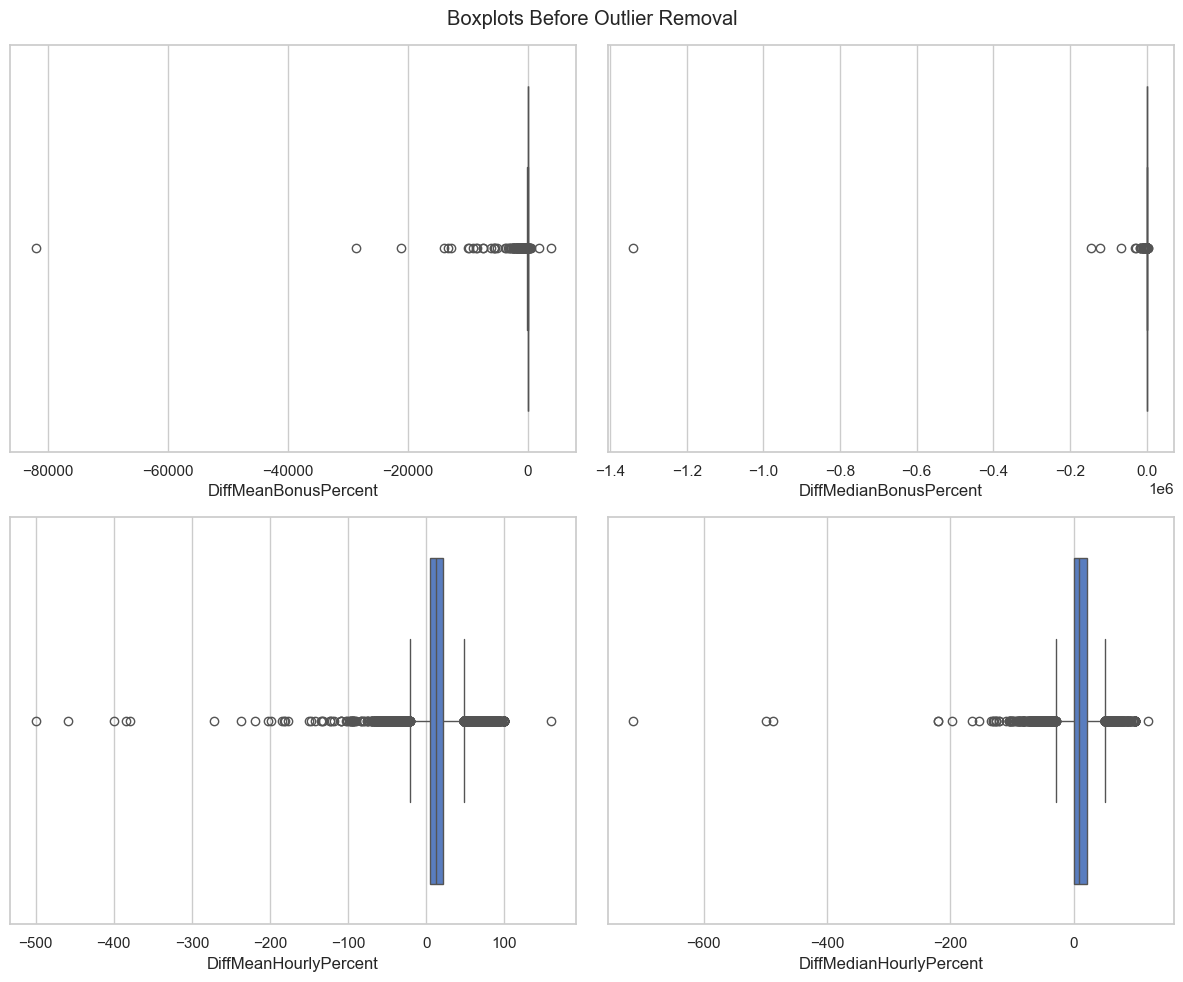

In [25]:
# 1. Box plots before outlier removal
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
sns.boxplot(ax=axes[0, 0], x=df['DiffMeanBonusPercent'])
sns.boxplot(ax=axes[0, 1], x=df['DiffMedianBonusPercent'])
sns.boxplot(ax=axes[1, 0], x=df['DiffMeanHourlyPercent'])
sns.boxplot(ax=axes[1, 1], x=df['DiffMedianHourlyPercent'])
fig.suptitle('Boxplots Before Outlier Removal')
plt.tight_layout()

# Show before plots
plt.show()

- ##### There are Extreme outliers in these columns that is effecting our analysis. We will use IQR method to filter out these outliers from our data

In [26]:
# Example using IQR method for multiple columns
for col in ['DiffMeanBonusPercent', 'DiffMedianBonusPercent', 
            'DiffMeanHourlyPercent', 'DiffMedianHourlyPercent']:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    df_clean = df_clean[(df_clean[col] >= Q1 - 1.5 * IQR) & (df_clean[col] <= Q3 + 1.5 * IQR)]

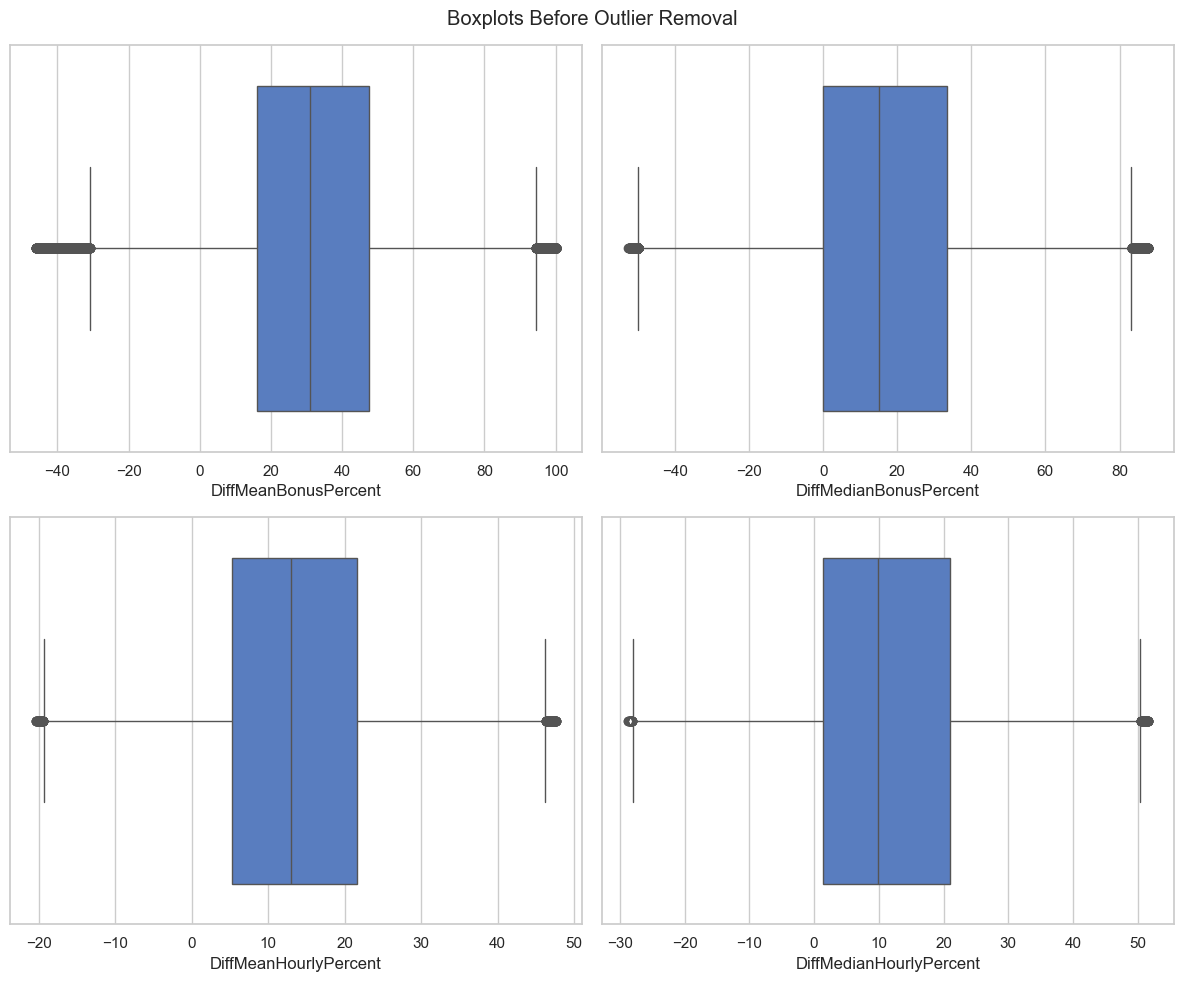

In [27]:
# 1. Box plots before outlier removal
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
sns.boxplot(ax=axes[0, 0], x=df_clean['DiffMeanBonusPercent'])
sns.boxplot(ax=axes[0, 1], x=df_clean['DiffMedianBonusPercent'])
sns.boxplot(ax=axes[1, 0], x=df_clean['DiffMeanHourlyPercent'])
sns.boxplot(ax=axes[1, 1], x=df_clean['DiffMedianHourlyPercent'])
fig.suptitle('Boxplots Before Outlier Removal')
plt.tight_layout()

# Show before plots
plt.show()

#### Create new feature city and region from the Adress column

In [28]:
df_clean['Address'] = df_clean['Address'].astype(str)  # Ensure the column is string

# Your city list (from the UK gov)
cities = [
    "Bath", "Birmingham", "Bradford", "Brighton & Hove", "Bristol", "Cambridge", "Canterbury",
    "Carlisle", "Chelmsford", "Chester", "Chichester", "Colchester", "Coventry", "Derby",
    "Doncaster", "Durham", "Ely", "Exeter", "Gloucester", "Hereford", "Kingston-upon-Hull",
    "Lancaster", "Leeds", "Leicester", "Lichfield", "Lincoln", "Liverpool", "London",
    "Manchester", "Milton Keynes", "Newcastle-upon-Tyne", "Norwich", "Nottingham", "Oxford",
    "Peterborough", "Plymouth", "Portsmouth", "Preston", "Ripon", "Salford", "Salisbury",
    "Sheffield", "Southampton", "Southend-on-Sea", "St Albans", "Stoke on Trent", "Sunderland",
    "Truro", "Wakefield", "Wells", "Westminster", "Winchester", "Wolverhampton", "Worcester", "York",
    "Armagh", "Bangor", "Belfast", "Lisburn", "Londonderry", "Newry",
    "Aberdeen", "Dundee", "Dunfermline", "Edinburgh", "Glasgow", "Inverness", "Perth", "Stirling",
    "Cardiff", "Newport", "St Asaph", "St Davids", "Swansea", "Wrexham"
]

# Region keywords (grouped loosely by UK countries)
regions = ["Northern Ireland", "Scotland", "Wales", "England"]  # You can expand with counties if needed

# Compile regex pattern from cities
city_pattern = r'\b(?:' + '|'.join(re.escape(city) for city in sorted(cities, key=len, reverse=True)) + r')\b'
region_pattern = r'\b(?:' + '|'.join(re.escape(region) for region in sorted(regions, key=len, reverse=True)) + r')\b'

# Extract city and region using regex
df_clean['city'] = df_clean['Address'].str.extract(f'({city_pattern})', flags=re.IGNORECASE, expand=False).str.title()
df_clean['region'] = df_clean['Address'].str.extract(f'({region_pattern})', flags=re.IGNORECASE, expand=False).str.title()

# Display result
df_clean[['Address', 'city', 'region']].head(10)

,Address,city,region
0,"Suite 1, Ground Floor Academy House, 1346 Shet...",Glasgow,Scotland
1,"30 Fenchurch Street, London, England, EC3M 3BD",London,England
2,"48 High Street, Gravesend, Kent, England, DA11...",NaN,England
3,"Bartle House, Oxford Court, Manchester, Englan...",Oxford,England
4,"Unit 1 Radford Industrial Estate, Goodhall Str...",London,England
5,"The Old Dairy, Leed Street, Wigan, United King...",NaN,NaN
6,"Weston Centre, 10 Grosvenor Street, London, W1...",London,NaN
8,"1 Chequers Road, Basingstoke, Hampshire, Engla...",NaN,England
9,"Kintail House, Forthside Way, Stirling, Stirli...",Stirling,Scotland
10,"Weston Centre, 10 Grosvenor Street, London, W1...",London,NaN


In [29]:
df_clean['region'].value_counts()

region
England             16782
Scotland             1074
Wales                 513
Northern Ireland       41
Name: count, dtype: int64

In [30]:
df_clean['city'].value_counts()

city
London                14006
Birmingham             1400
Manchester             1270
Leeds                  1056
Bristol                 927
                      ...  
Londonderry               8
St Davids                 7
Newry                     6
Armagh                    3
Kingston-Upon-Hull        3
Name: count, Length: 73, dtype: int64

# **The Analysis**

**Average Gender Pay Gap Over Time**

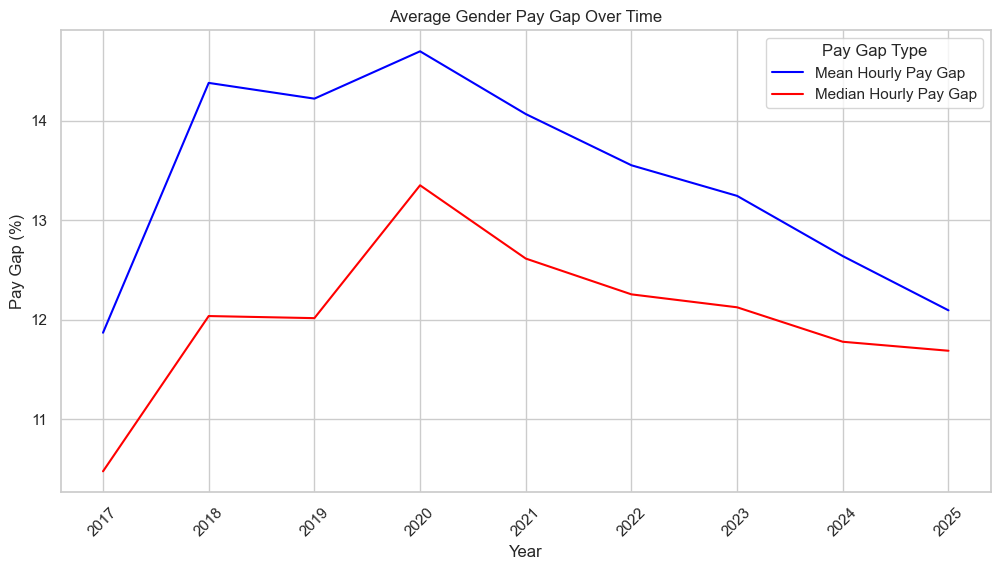

In [31]:
# Extract the year from the DateSubmitted column
df_clean['year'] = pd.to_datetime(df_clean['DateSubmitted']).dt.year

# Group by year and calculate the mean of hourly and median pay gaps
df_avg_gap_yearly = df_clean.groupby('year')[['DiffMeanHourlyPercent', 'DiffMedianHourlyPercent']].mean().reset_index()

# Plot the line chart to show the trend over time
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_avg_gap_yearly, x='year', y='DiffMeanHourlyPercent', label='Mean Hourly Pay Gap', color='blue')
sns.lineplot(data=df_avg_gap_yearly, x='year', y='DiffMedianHourlyPercent', label='Median Hourly Pay Gap', color='red')

plt.title('Average Gender Pay Gap Over Time')
plt.xlabel('Year')
plt.ylabel('Pay Gap (%)')
plt.legend(title='Pay Gap Type')
plt.xticks(rotation=45)
plt.show()

## Average Gender Pay Gap Over Time
**Insight:** 

The gender pay gap peaked in 2020 at 15% (mean) and 13.4% (median), then steadily declined to 12.1% and 11.7% by 2025. The persistent gap between mean and median indicates high-earning outliers influence the average.

**Recommendation:** 

Continue tracking this encouraging downward trend. Investigate specific industries and roles where gaps persist, especially in high-paying positions that drive the mean-median difference.

## Side-by-Side Comparisons for Hourly vs. Bonus Gaps

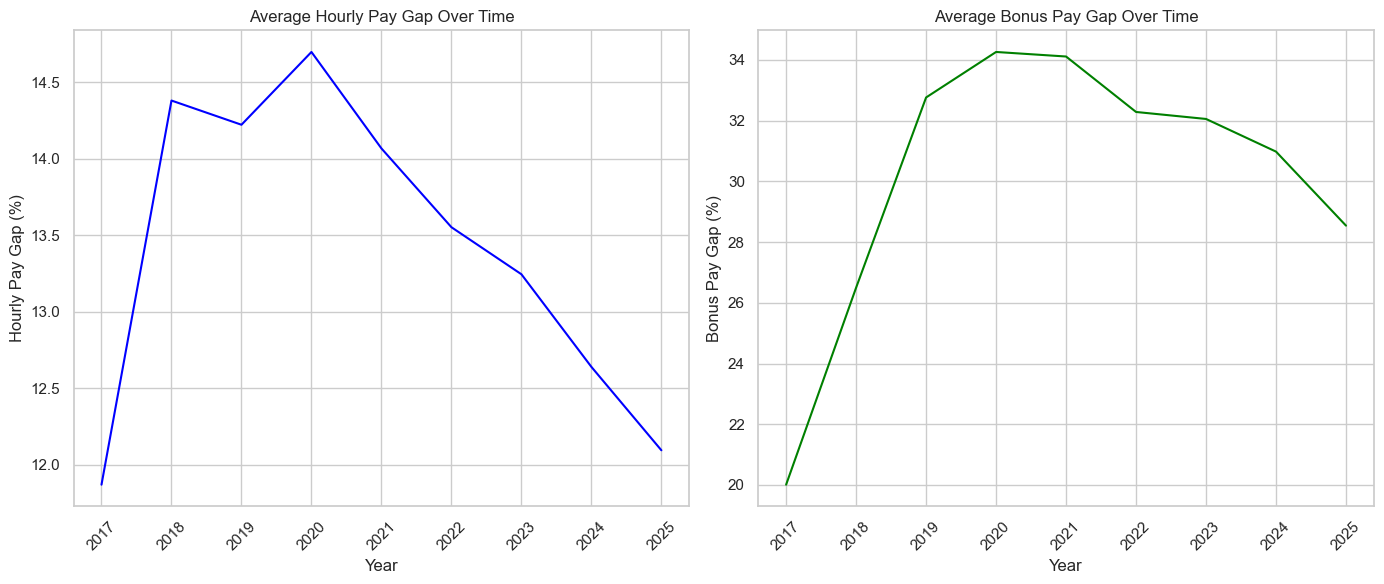

In [32]:
# Group by year and calculate the mean of hourly and bonus pay gaps
df_avg_gap_yearly_bonus = df_clean.groupby('year')[['DiffMeanHourlyPercent', 'DiffMeanBonusPercent']].mean().reset_index()

# Create a figure with two subplots
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# Plot the first chart for Hourly Pay Gap
sns.lineplot(data=df_avg_gap_yearly_bonus, x='year', y='DiffMeanHourlyPercent', ax=ax[0], color='blue')
ax[0].set_title('Average Hourly Pay Gap Over Time')
ax[0].set_xlabel('Year')
ax[0].set_ylabel('Hourly Pay Gap (%)')
ax[0].set_xticklabels(ax[0].get_xticklabels(), rotation=45)

# Plot the second chart for Bonus Pay Gap
sns.lineplot(data=df_avg_gap_yearly_bonus, x='year', y='DiffMeanBonusPercent', ax=ax[1], color='green')
ax[1].set_title('Average Bonus Pay Gap Over Time')
ax[1].set_xlabel('Year')
ax[1].set_ylabel('Bonus Pay Gap (%)')
ax[1].set_xticklabels(ax[1].get_xticklabels(), rotation=45)

plt.tight_layout()
plt.show()

## Hourly vs Bonus Pay Gaps
**Insight:** 

Bonus gaps (28-34%) are substantially larger than hourly gaps (12-14.7%), both peaking in 2020 and declining since. The bonus gap remains more than double the hourly gap.

**Recommendation:** 

Prioritize bonus allocation reform with transparent criteria. The significantly larger bonus gap reveals where bias likely operates most freely.

## Bar Chart: Employer Size vs DiffMeanHourlyPercent (Aggregated Mean)

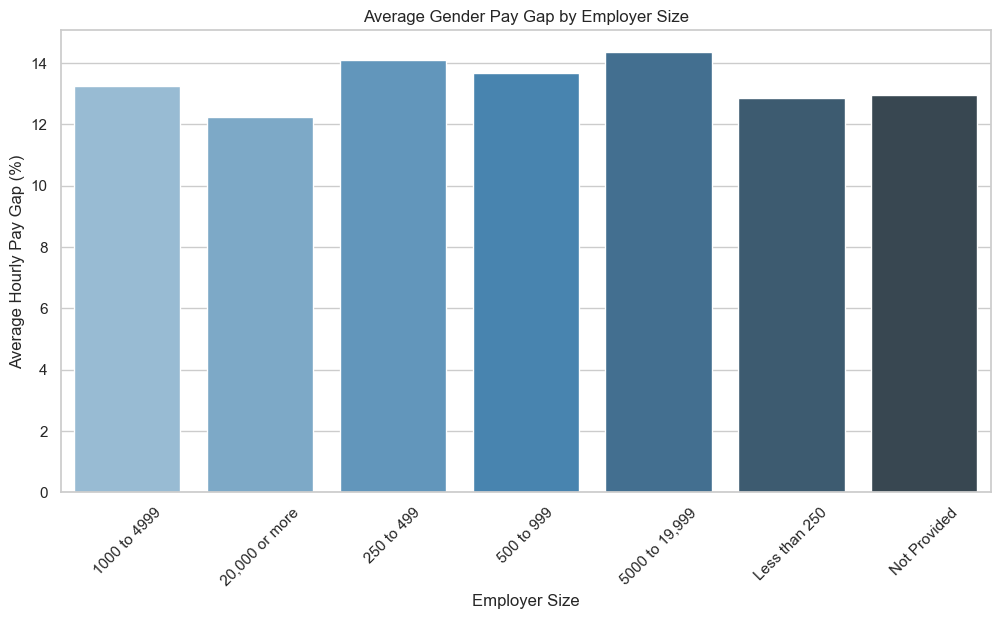

In [33]:
# Group by EmployerSize and calculate the mean DiffMeanHourlyPercent for each size category
df_avg_gap_size = df_clean.groupby('EmployerSize')['DiffMeanHourlyPercent'].mean().reset_index()

# Plot the bar chart to visualize the average hourly pay gap by employer size
plt.figure(figsize=(12, 6))
sns.barplot(data=df_avg_gap_size, x='EmployerSize', y='DiffMeanHourlyPercent', palette='Blues_d')
plt.title('Average Gender Pay Gap by Employer Size')
plt.xlabel('Employer Size')
plt.ylabel('Average Hourly Pay Gap (%)')
plt.xticks(rotation=45)
plt.show()

## Pay Gap by Employer Size
**Insight:** 

Mid-large organizations (5,000-19,999 employees) show the highest gap (14.2%), while the very largest (20,000+) and smallest companies have lower gaps (around 12.2%).

**Recommendation:** 

Target interventions at mid-sized organizations that may lack both the accountability structures of large companies and the flexibility of small ones.

## Boxplots by Employer Size

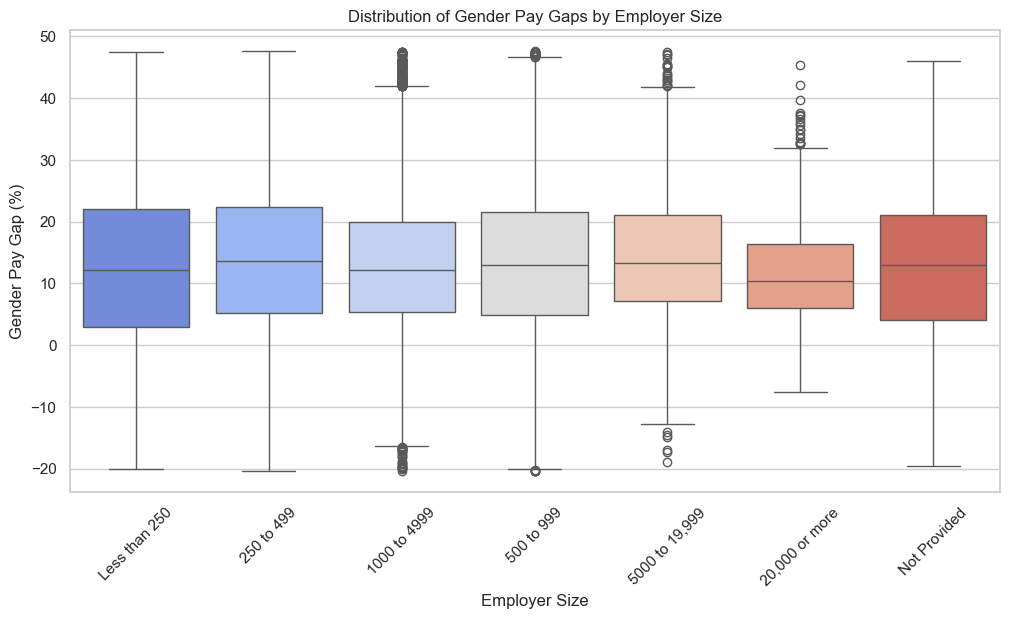

In [34]:
# Plotting the boxplot to show the distribution of pay gaps by employer size
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_clean, x='EmployerSize', y='DiffMeanHourlyPercent', palette='coolwarm')
plt.title('Distribution of Gender Pay Gaps by Employer Size')
plt.xlabel('Employer Size')
plt.ylabel('Gender Pay Gap (%)')
plt.xticks(rotation=45)
plt.show()

## Distribution of Pay Gaps by Employer Size
**Insight:** 

All size categories show median gaps between 10-14%, but with different spreads. Largest organizations show the most consistent patterns, while mid-sized companies have more extreme outliers.

**Recommendation:** 

Identify outlier companies in each size category for both best and worst practices. Study what drives consistency in larger organizations.

## Visualize the Gender Pay Gap by Sector

In [35]:
def map_sic_to_sector(sic):
    """
    Map a SIC code (as a string) to a broad UK business sector.
    This example uses the first two digits of the numeric portion.
    """
    # Remove any non-digit characters
    code = ''.join(filter(str.isdigit, sic))
    if not code:
        return "Unknown"
    try:
        # Use the first two digits for classification
        prefix = int(code[:2])
    except Exception:
        return "Unknown"
    
    # Simplified rules (adjust as needed)
    if 1 <= prefix <= 3:
        return "Agriculture, Forestry & Fishing"
    elif 10 <= prefix <= 33:
        return "Manufacturing"
    elif 35 <= prefix <= 39:
        return "Utilities"
    elif 41 <= prefix <= 43:
        return "Construction"
    elif 45 <= prefix <= 47:
        return "Wholesale & Retail Trade"
    elif 49 <= prefix <= 53:
        return "Transportation & Storage"
    elif prefix == 55:
        return "Accommodation & Food Services"
    elif 58 <= prefix <= 63:
        return "Information & Communication"
    elif 64 <= prefix <= 66:
        return "Financial & Insurance"
    elif prefix == 68:
        return "Real Estate"
    elif 69 <= prefix <= 75:
        return "Professional, Scientific & Technical Activities"
    elif 77 <= prefix <= 82:
        return "Administrative & Support Services"
    elif prefix == 84:
        return "Public Administration & Defence"
    elif prefix == 85:
        return "Education"
    elif 86 <= prefix <= 88:
        return "Human Health & Social Work"
    elif prefix == 90:
        return "Arts, Entertainment & Recreation"
    elif 91 <= prefix <= 93:
        return "Other Service Activities"
    elif prefix == 94:
        return "Households as Employers"
    elif prefix == 95:
        return "Extraterrestrial Organizations"
    else:
        return "Other"

In [36]:
def process_sic_codes(sic_str):
    """
    Given a string of one or more SIC codes (separated by commas and/or newline),
    split the string, map each individual code to a sector using map_sic_to_sector,
    and return a comma-separated string of unique sector names.
    """
    if not isinstance(sic_str, str):
        return "Unknown"
    # Split the string on commas and newline characters
    codes = re.split(r'[,\\n]+', sic_str)
    codes = [code.strip() for code in codes if code.strip()]
    # Map each code to a business sector
    sectors = [map_sic_to_sector(code) for code in codes]
    # Remove duplicate sectors
    unique_sectors = sorted(set(sectors))
    return ", ".join(unique_sectors)

# Assume the SIC code column is named "SICCode"
df['Business Sector'] = df['SicCodes'].apply(process_sic_codes)

In [37]:
sector_counter = Counter()
for sectors in df['Business Sector']:
    # Split by comma and strip whitespace
    for sector in sectors.split(","):
        sector = sector.strip()
        if sector:
            sector_counter[sector] += 1

# Convert to a DataFrame for plotting
sector_counts = pd.DataFrame(sector_counter.items(), columns=['Business Sector', 'Count'])
sector_counts = sector_counts.sort_values(by='Count', ascending=False)

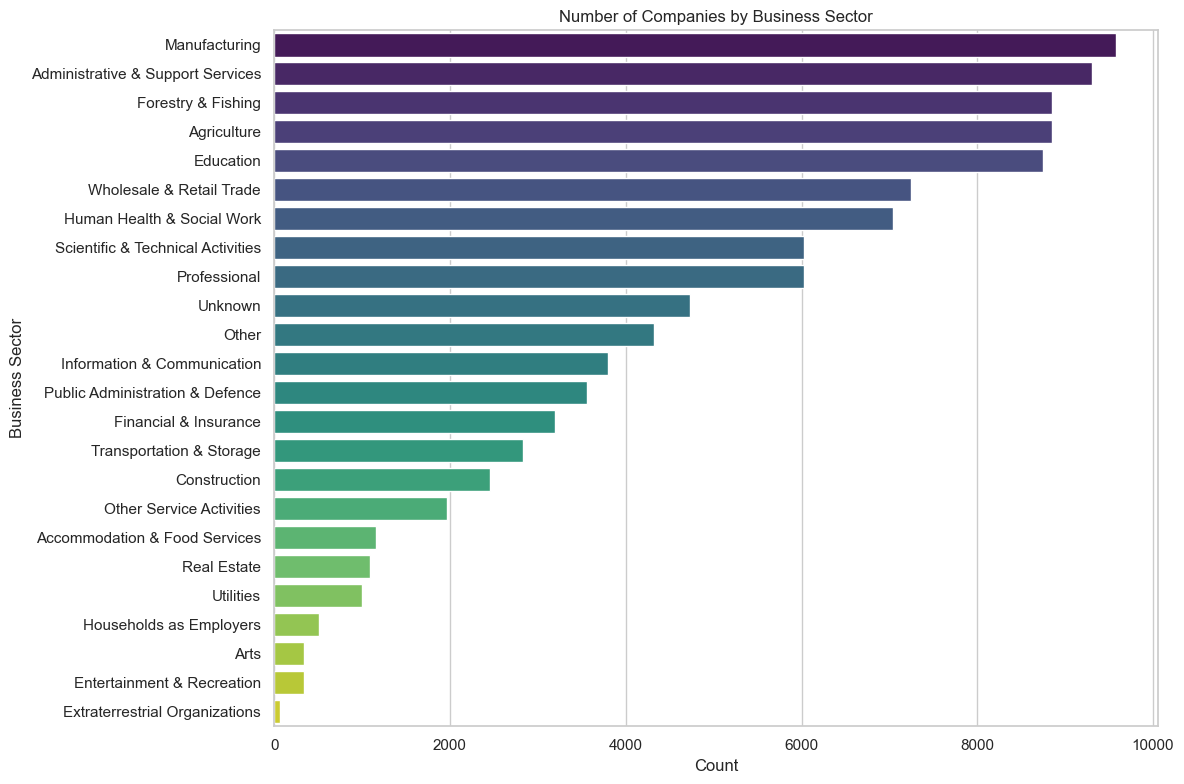

In [38]:
plt.figure(figsize=(12, 8))
sns.barplot(data=sector_counts, x='Count', y='Business Sector', palette="viridis")
plt.title("Number of Companies by Business Sector")
plt.xlabel("Count")
plt.ylabel("Business Sector")
plt.tight_layout()
plt.show()

## Companies by Business Sector
**Insight:** 

Manufacturing and Administrative Services have the highest representation in the dataset, while Arts and Entertainment sectors have minimal representation.

**Recommendation:** 

Ensure interventions account for industry composition, with targeted strategies for dominant sectors that will have the most impact on overall statistics.

## Average Gender Pay Gap by Region

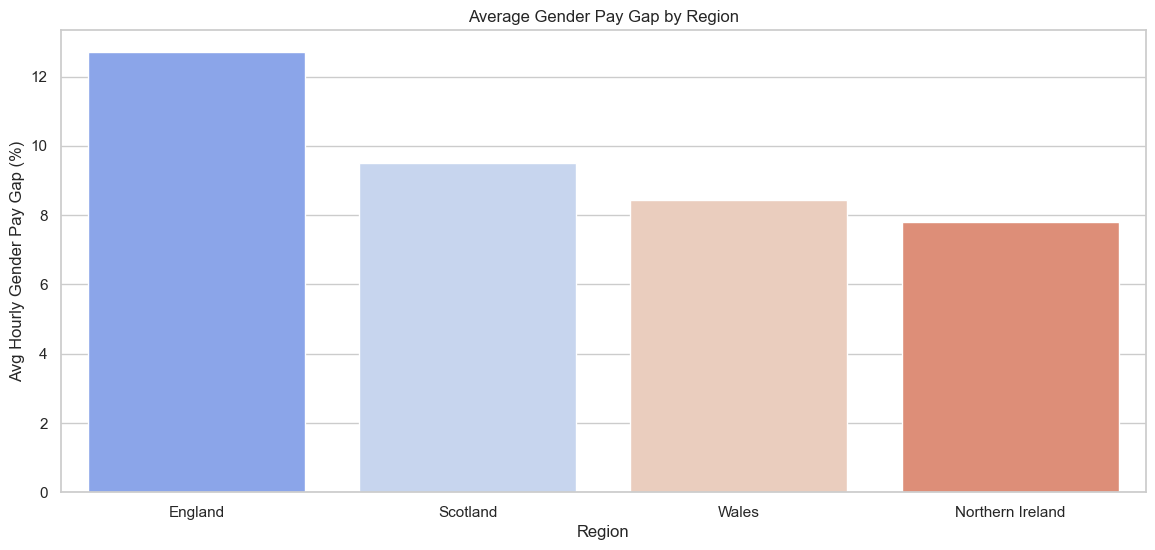

In [39]:
plt.figure(figsize=(14,6))

df_region_sorted = df_clean.sort_values("DiffMedianHourlyPercent", ascending=False)
# Plot using the sorted DataFrame
sns.barplot(
    data=df_region_sorted,
    x="region",
    y="DiffMedianHourlyPercent",
    palette="coolwarm",
    ci=None  # Remove error bars
)

plt.title("Average Gender Pay Gap by Region")
plt.ylabel("Avg Hourly Gender Pay Gap (%)")
plt.xlabel("Region")
plt.show()

## Pay Gap by Region
**Insight:** 

England shows the highest gender pay gap (12.5%), while Northern Ireland has the lowest (7.8%). This regional variation suggests structural differences in labor markets.

**Recommendation:** 

Study Northern Ireland's policies and practices as potential models. Address England's larger gap with targeted regional initiatives.

## Stacked Bar Chart: Female vs Male Top Quartile per Year

<Figure size 1200x600 with 0 Axes>

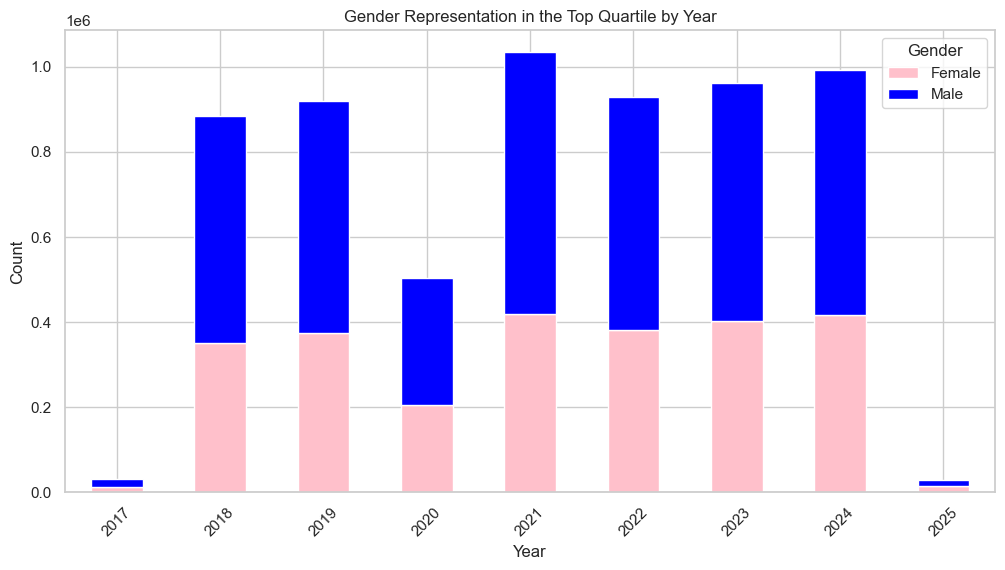

In [40]:
# Group by year and sum the FemaleTopQuartile and MaleTopQuartile for each year
df_top_quartile = df_clean.groupby('year')[['FemaleTopQuartile', 'MaleTopQuartile']].sum().reset_index()

# Plot the stacked bar chart to compare Female and Male representation in the Top Quartile
plt.figure(figsize=(12, 6))
df_top_quartile.set_index('year')[['FemaleTopQuartile', 'MaleTopQuartile']].plot(kind='bar', stacked=True, color=['pink', 'blue'], figsize=(12, 6))

plt.title('Gender Representation in the Top Quartile by Year')
plt.xlabel('Year')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='Gender', labels=['Female', 'Male'])
plt.show()

## Gender Representation in Top Quartile
**Insight:** 

Female representation in top earnings quartile dramatically increased from 2017-2018, reaching about 40% by 2024. The 2021 data shows near parity before regressing slightly.

**Recommendation:** 

Investigate what drove the 2021 peak and subsequent regression. The 2017/2025 data anomalies need verification for data quality issues.

## Quartile Difference Over Time (Line or Area Chart)

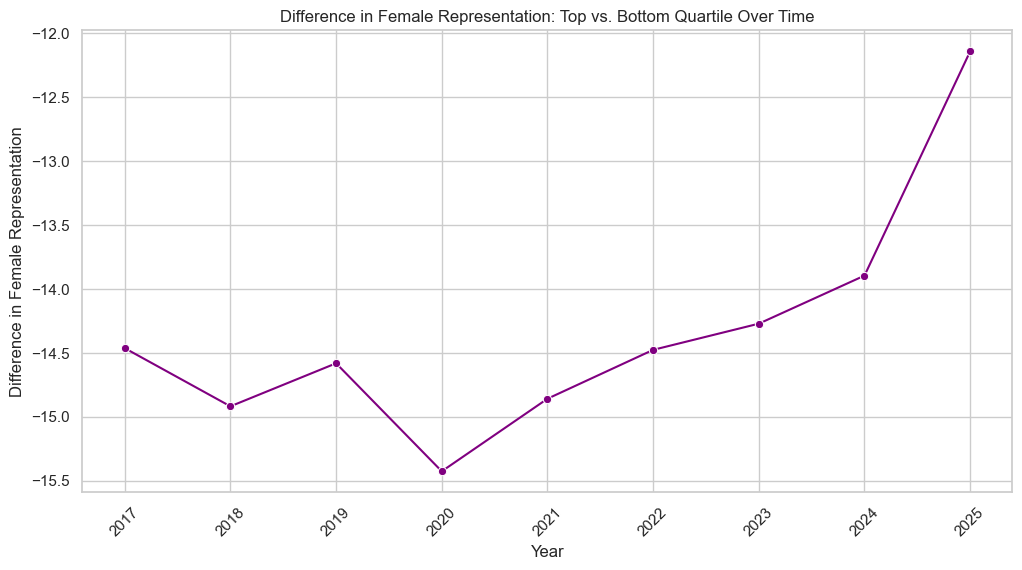

In [41]:
# Calculate the difference between FemaleTopQuartile and FemaleLowerQuartile for each year
df_clean['FemaleTopMinusBottomQuartile'] = df_clean['FemaleTopQuartile'] - df_clean['FemaleLowerQuartile']

# Group by year and calculate the mean of the difference for each year
df_quartile_diff = df_clean.groupby('year')['FemaleTopMinusBottomQuartile'].mean().reset_index()

# Plot the line chart to show the difference in female representation between top and bottom quartiles over time
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_quartile_diff, x='year', y='FemaleTopMinusBottomQuartile', color='purple', marker='o')

plt.title('Difference in Female Representation: Top vs. Bottom Quartile Over Time')
plt.xlabel('Year')
plt.ylabel('Difference in Female Representation')
plt.xticks(rotation=45)
plt.show()

## Female Representation Difference (Top vs Bottom)
**Insight:** 

The negative values show fewer women in top quartiles than bottom quartiles, but this gap has improved steadily since 2020, with dramatic improvement in 2024-2025.

**Recommendation:** 

Study and amplify the factors driving the recent acceleration in improvement. Use the 2024-2025 period as a case study for effective interventions.

## Boxplot: DiffMeanBonusPercent vs. DiffMeanHourlyPercent

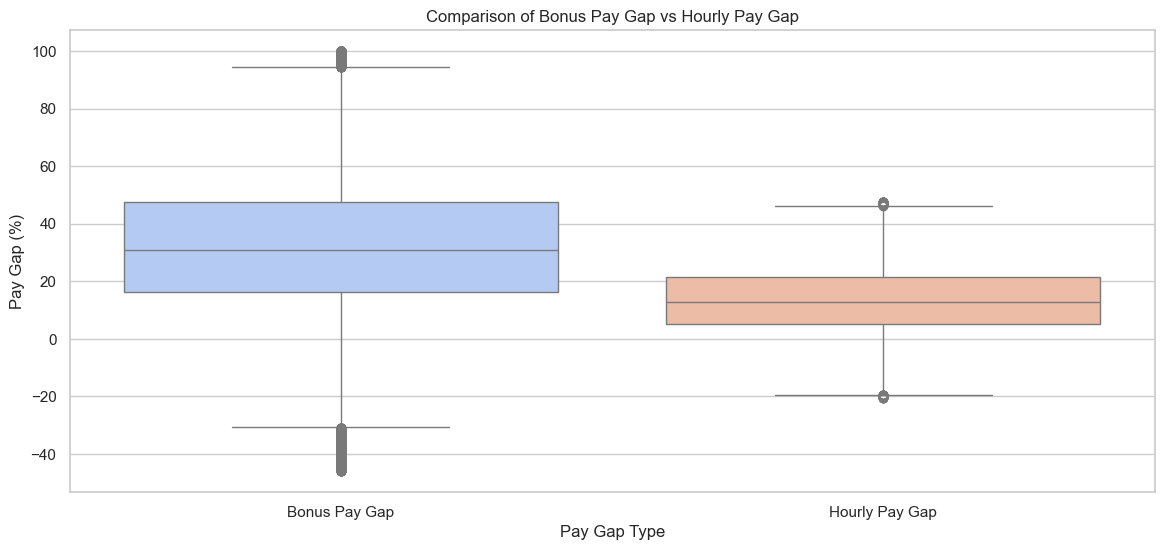

In [42]:
# Plot the boxplot to compare DiffMeanBonusPercent vs DiffMeanHourlyPercent
plt.figure(figsize=(14, 6))
sns.boxplot(data=df_clean[['DiffMeanBonusPercent', 'DiffMeanHourlyPercent']], palette='coolwarm')
plt.title('Comparison of Bonus Pay Gap vs Hourly Pay Gap')
plt.xlabel('Pay Gap Type')
plt.ylabel('Pay Gap (%)')
plt.xticks([0, 1], ['Bonus Pay Gap', 'Hourly Pay Gap'])
plt.show()

## Bonus vs Hourly Pay Gap Comparison
**Insight:** 

Bonus pay gaps show both higher median (30% vs 13%) and more extreme outliers (up to 100%) than hourly pay gaps, confirming bonus allocation as a major inequality driver.

**Recommendation:** 

Audit bonus systems with extreme gaps. Establish standardized, transparent bonus criteria to reduce subjective decision-making.

## Bar Chart: Male vs Female Bonus Percent by Year or Sector

<Figure size 1200x600 with 0 Axes>

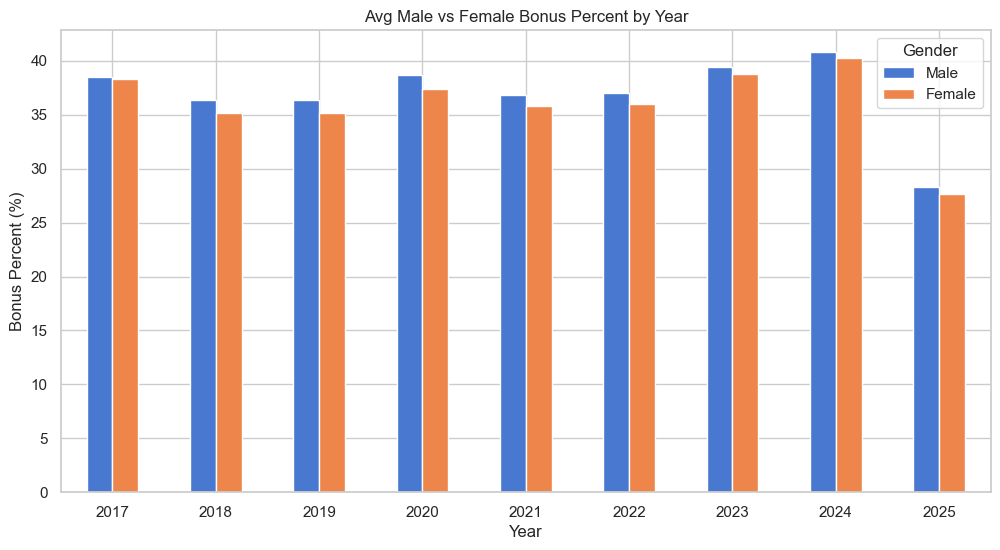

In [43]:
# Group by year and calculate the mean MaleBonusPercent and FemaleBonusPercent
df_bonus_by_year = df_clean.groupby('year')[['MaleBonusPercent', 'FemaleBonusPercent']].mean().reset_index()

# Plot the bar chart to compare Male and Female Bonus Percent by year
plt.figure(figsize=(12, 6))
df_bonus_by_year.set_index('year')[['MaleBonusPercent', 'FemaleBonusPercent']].plot(kind='bar', figsize=(12, 6))
plt.title('Avg Male vs Female Bonus Percent by Year')
plt.xlabel('Year')
plt.ylabel('Bonus Percent (%)')
plt.xticks(rotation=0)
plt.legend(title='Gender', labels=['Male', 'Female'])
plt.show()

## Male vs Female Bonus Percentages
**Insight:** 

Male bonus percentages consistently exceed female percentages across years. The gap narrowed in 2023-2024 before both dropped significantly in 2025.

**Recommendation:** 

Investigate the 2025 bonus reduction and its gender implications. Sustain the narrowing trend while addressing the overall compensation decrease.

## Pie Chart: Percentage of Companies That Submit Late

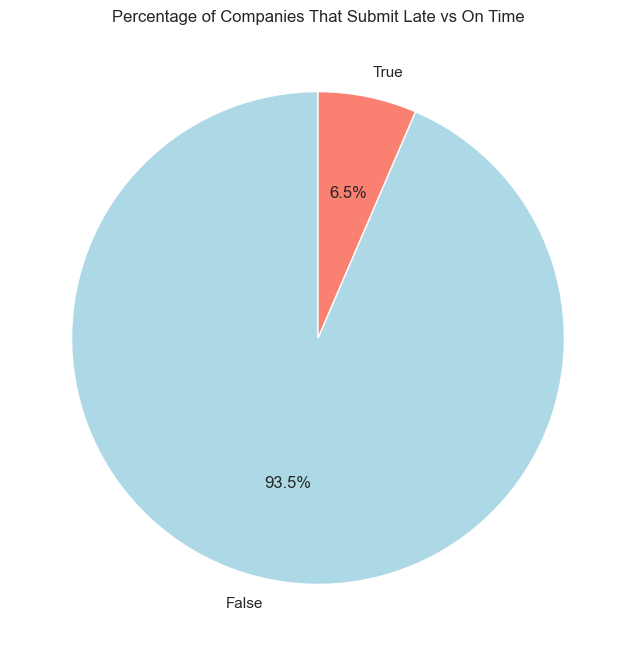

In [44]:
# Calculate the number of late and on-time submissions
submission_status = df_clean['SubmittedAfterTheDeadline'].value_counts()

# Plot the pie chart for late vs on-time submissions
plt.figure(figsize=(8, 8))
submission_status.plot(kind='pie', autopct='%1.1f%%', colors=['lightblue', 'salmon'], startangle=90, cmap='coolwarm')
plt.title('Percentage of Companies That Submit Late vs On Time')
plt.ylabel('')
plt.show()

## Reporting Compliance
**Insight:** 

Strong reporting compliance with 93.5% of companies submitting on time, while only 6.5% report late.

**Recommendation:** 

Focus compliance efforts on the small percentage of late reporters, while ensuring the reporting system remains accessible and straightforward.

## Boxplot or Violin Plot: DiffMeanHourlyPercent by

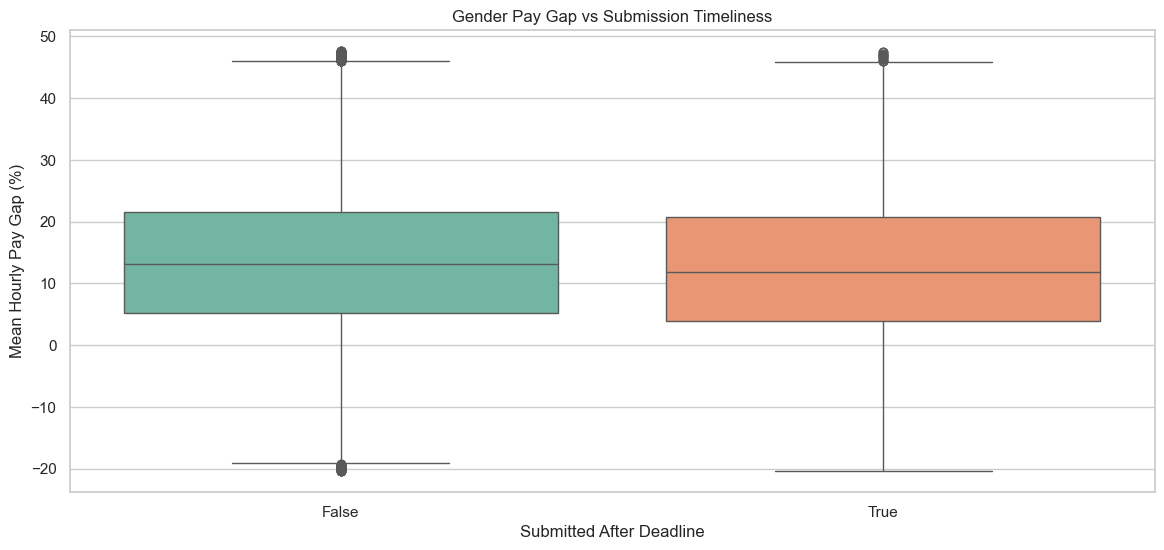

In [45]:
# Plot a boxplot to compare DiffMeanHourlyPercent for companies that submitted late vs on time
plt.figure(figsize=(14, 6))
sns.boxplot(data=df_clean, x='SubmittedAfterTheDeadline', y='DiffMeanHourlyPercent', palette='Set2')
plt.title('Gender Pay Gap vs Submission Timeliness')
plt.xlabel('Submitted After Deadline')
plt.ylabel('Mean Hourly Pay Gap (%)')
plt.show()

## Pay Gap vs Reporting Timeliness
**Insight:** 

No significant difference exists between on-time and late reporters in their pay gap distributions, suggesting timeliness doesn't correlate with equality practices.

**Recommendation:** 

Focus on actual pay practices rather than reporting behavior. Late reporting doesn't appear to be a signal of problematic gap patterns.